# Effect Sizes and Power Analysis — Extended


Builds on `ipynb/statistical_power_analysis_professional.ipynb`. For every
model in Notebooks 1 and 2 (OLS, Ridge, LASSO, Elastic Net, Random Forest, CNN),
this notebook reports:

- **Post-hoc effect size** — R² from CV out-of-fold predictions, Cohen's
  f² = R² / (1 − R²), bootstrap 95% CIs.
- **Achieved power** — given that effect size at the actual N and the *honest*
  number of predictors (= number of selected features for LASSO/Elastic Net).
- **Required N for 80% power** —
- **Per-feature partial η²** — which autoantibodies are individually
  well-powered vs riding on the panel.
- **Inter-study heterogeneity** — meta-analysis I² across per-study OLS slopes.
- **Leave-one-study-out sensitivity** — does any one study (especially SDY797
  or SDY524) drive the conclusion?

**Outputs:** `results/effect_sizes_*.csv`, `figures/achieved_power_*.pdf`.


## 1. Setup

In [1]:
from __future__ import annotations
import sys, os, warnings, json
from pathlib import Path
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

REPO = Path.cwd()
if (REPO / "src").exists():
    sys.path.insert(0, str(REPO / "src"))
elif (REPO.parent / "src").exists():
    REPO = REPO.parent
    sys.path.insert(0, str(REPO / "src"))
os.chdir(REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.power import FTestPower
from sklearn.linear_model import LinearRegression, Ridge, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

import oadr_data as od

RNG_SEED = 42
N_BOOT = 1000
N_FOLDS = 5
ALPHA = 0.05
TARGET_POWER = 0.80
np.random.seed(RNG_SEED)

(REPO / "results").mkdir(exist_ok=True)
(REPO / "figures").mkdir(exist_ok=True)


In [2]:
from scipy.stats import f as fdist, ncf


def calc_power(n, k, f2, alpha=ALPHA):
    """Power for multiple regression: F-test with non-centrality nc = f² × N."""
    if n <= k + 1 or f2 <= 0:
        return float("nan")
    df_num, df_denom = k, n - k - 1
    F_crit = fdist.ppf(1 - alpha, df_num, df_denom)
    nc = f2 * n
    return float(1 - ncf.cdf(F_crit, df_num, df_denom, nc))


def mde_f2(n, k, power=TARGET_POWER, alpha=ALPHA, lo=1e-6, hi=10.0):
    """Bisect for the smallest f² that gives `power` at this N, k."""
    if calc_power(n, k, hi, alpha) < power:
        return float("nan")
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if calc_power(n, k, mid, alpha) >= power:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def cohens_f2(r2):
    r2 = max(r2, 0)
    if r2 >= 1:
        return float("inf")
    return r2 / (1 - r2)


def required_n_for_power(f2, k, target=TARGET_POWER, alpha=ALPHA, n_max=10_000):
    if f2 <= 0:
        return None
    lo, hi = k + 2, n_max
    while lo < hi:
        mid = (lo + hi) // 2
        if calc_power(mid, k, f2, alpha) >= target:
            hi = mid
        else:
            lo = mid + 1
    return lo if calc_power(lo, k, f2, alpha) >= target else None


### A note on `src/oadr_data.py`

`oadr_data` is the single utility file that resolves all the per-study
quirks (column-name typos, `IA_2ic` ↔ `IA2IC` mismatches, age-group
recoding, per-study autoantibody-set differences, extended feature panel
merging). It is the only piece of shared code in this project; everything
else in each notebook is intended to be readable top-to-bottom. Open
`src/oadr_data.py` if you want to read the cleanup line by line.

The two functions used here are:

- `load_panel_a_all()` → 150 subjects × 9 features (minimal feature panel)
- `load_panel_b_all()` → 98 subjects × 23 features (extended feature panel)


In [3]:
A = od.load_panel_a_all()
Xa, ya, fa = od.panel_a_design_matrix(A)
B = od.load_panel_b_all()
Xb, yb, fb = od.panel_b_design_matrix(B)
print(f"Panel A: N={len(A)}, k_nominal={len(fa)}")
print(f"Panel B: N={len(B)}, k_nominal={len(fb)}")


Panel A: N=150, k_nominal=9
Panel B: N=98, k_nominal=23


## 2. Recap a-priori power

Using the existing study design (N=154, k=9, α=0.05), what effects could the
study reliably detect *before* we looked at the data? This is independent of any model fit.


In [4]:
N_NOMINAL = 154   # design value
K_NOMINAL = 9
apriori_rows = []
for r2 in (0.05, 0.10, 0.15, 0.20, 0.30, 0.50):
    f2 = cohens_f2(r2)
    p = calc_power(N_NOMINAL, K_NOMINAL, f2)
    apriori_rows.append({"R2": r2, "Cohen_f2": f2, "achieved_power": p})
apriori = pd.DataFrame(apriori_rows)
print(f"A-priori power at N={N_NOMINAL}, k={K_NOMINAL}, α={ALPHA}:")
print(apriori.to_string(index=False))

mde = mde_f2(N_NOMINAL, K_NOMINAL, TARGET_POWER, ALPHA)
print(f"\nMinimum detectable Cohen's f² at {int(TARGET_POWER*100)}% power: {mde:.4f}")
print(f"Equivalent R²: {mde / (1 + mde):.4f}")
apriori.to_csv("results/effect_sizes_apriori.csv", index=False)


A-priori power at N=154, k=9, α=0.05:
  R2  Cohen_f2  achieved_power
0.05  0.052632        0.434594
0.10  0.111111        0.815031
0.15  0.176471        0.966573
0.20  0.250000        0.996719
0.30  0.428571        0.999996
0.50  1.000000        1.000000

Minimum detectable Cohen's f² at 80% power: 0.1077
Equivalent R²: 0.0972


## 3. Per-model post-hoc effect sizes (Panel A)

Compute R² from OOF predictions, derive Cohen's f², bootstrap 95% CI on R².
For LASSO/Elastic Net, use *number of selected features* as `k_effective`.
For Random Forest and CNN we use the nominal k=9 (these models don't shrink
features in the LASSO sense; the parameter count is much higher, so this is a
conservative — friendly to the linear models — choice).

**Terminology**

*Cross-Validation Out-Of-Fold predict.*

* **CV** = cross-validation
* **OOF** = out-of-fold
* **predict** = produces predictions


In [5]:
def cv_oof_predict(model_factory, X, y, study_labels, n_splits=N_FOLDS, seed=RNG_SEED):
    X = np.asarray(X); y = np.asarray(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof = np.full_like(y, np.nan, dtype=float)
    selected_per_fold = []
    for tr, te in skf.split(X, study_labels):
        m = model_factory()
        m.fit(X[tr], y[tr])
        oof[te] = m.predict(X[te])
        # Track non-zero count if pipeline ends in a regularized linear model
        try:
            inner = m.named_steps["m"]
            if hasattr(inner, "coef_"):
                selected_per_fold.append(int(np.sum(inner.coef_ != 0)))
        except Exception:
            pass
    return oof, np.median(selected_per_fold) if selected_per_fold else None


def boot_r2(y_true, y_pred, n_boot=N_BOOT, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    boots = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=n, replace=True)
        boots.append(r2_score(y_true[idx], y_pred[idx]))
    return float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))


def make_pipe(model):
    return Pipeline([("sc", MinMaxScaler()), ("m", model)])


model_factories_A = {
    "OLS":         lambda: make_pipe(LinearRegression()),
    "Ridge":       lambda: make_pipe(Ridge(alpha=0.001)),
    "LASSO":       lambda: make_pipe(LassoCV(cv=5, random_state=RNG_SEED, max_iter=20000, n_alphas=50)),
    "ElasticNet":  lambda: make_pipe(ElasticNetCV(l1_ratio=[0.1,0.3,0.5,0.7,0.9], cv=5, random_state=RNG_SEED, max_iter=20000, n_alphas=50)),
    "RandomForest": lambda: make_pipe(RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RNG_SEED)),
}


rows_A = []
for name, factory in model_factories_A.items():
    oof, k_eff = cv_oof_predict(factory, Xa.values, ya.values, A["Study"].values)
    r2 = r2_score(ya.values, oof)
    r2_lo, r2_hi = boot_r2(ya.values, oof)
    f2 = cohens_f2(r2)
    f2_lo = cohens_f2(max(r2_lo, 0))
    f2_hi = cohens_f2(max(r2_hi, 0)) if r2_hi < 1 else float("inf")
    k_use = int(k_eff) if k_eff and k_eff > 0 else len(fa)
    pwr = calc_power(len(ya), k_use, max(f2, 1e-6))
    nreq = required_n_for_power(max(f2, 1e-6), k_use)
    rows_A.append({
        "Model": name, "Panel": "A", "N": len(ya), "k_used": k_use,
        "R2_oof": r2, "R2_ci_lo": r2_lo, "R2_ci_hi": r2_hi,
        "Cohen_f2": f2, "f2_ci_lo": f2_lo, "f2_ci_hi": f2_hi,
        "achieved_power": pwr, "N_required_for_80pct": nreq,
    })

# Repeat for Panel B
model_factories_B = dict(model_factories_A)  # same set
rows_B = []
for name, factory in model_factories_B.items():
    oof, k_eff = cv_oof_predict(factory, Xb.values, yb.values, B["Study"].values)
    r2 = r2_score(yb.values, oof)
    r2_lo, r2_hi = boot_r2(yb.values, oof)
    f2 = cohens_f2(r2)
    f2_lo = cohens_f2(max(r2_lo, 0))
    f2_hi = cohens_f2(max(r2_hi, 0)) if r2_hi < 1 else float("inf")
    k_use = int(k_eff) if k_eff and k_eff > 0 else len(fb)
    pwr = calc_power(len(yb), k_use, max(f2, 1e-6))
    nreq = required_n_for_power(max(f2, 1e-6), k_use)
    rows_B.append({
        "Model": name, "Panel": "B", "N": len(yb), "k_used": k_use,
        "R2_oof": r2, "R2_ci_lo": r2_lo, "R2_ci_hi": r2_hi,
        "Cohen_f2": f2, "f2_ci_lo": f2_lo, "f2_ci_hi": f2_hi,
        "achieved_power": pwr, "N_required_for_80pct": nreq,
    })

posthoc_df = pd.DataFrame(rows_A + rows_B)
print(posthoc_df.to_string(index=False))
posthoc_df.to_csv("results/effect_sizes_per_model.csv", index=False)


       Model Panel   N  k_used    R2_oof  R2_ci_lo  R2_ci_hi  Cohen_f2  f2_ci_lo  f2_ci_hi  achieved_power  N_required_for_80pct
         OLS     A 150       9 -0.026068 -0.174983  0.111345  0.000000       0.0  0.125296        0.050004                   NaN
       Ridge     A 150       9 -0.026050 -0.174953  0.111358  0.000000       0.0  0.125312        0.050004                   NaN
       LASSO     A 150       7 -0.062643 -0.174485  0.031968  0.000000       0.0  0.033023        0.050005                   NaN
  ElasticNet     A 150       7 -0.060772 -0.169824  0.031876  0.000000       0.0  0.032926        0.050005                   NaN
RandomForest     A 150       9 -0.120310 -0.265095  0.003947  0.000000       0.0  0.003962        0.050004                   NaN
         OLS     B  98      23 -0.019092 -0.328967  0.277191  0.000000       0.0  0.383492        0.050001                   NaN
       Ridge     B  98      21 -0.018495 -0.328416  0.277680  0.000000       0.0  0.384428       

## 4. Achieved-power forest plot

For each model on each panel: achieved power at the post-hoc f². Annotated with
the required N to reach 80% power if the effect held.


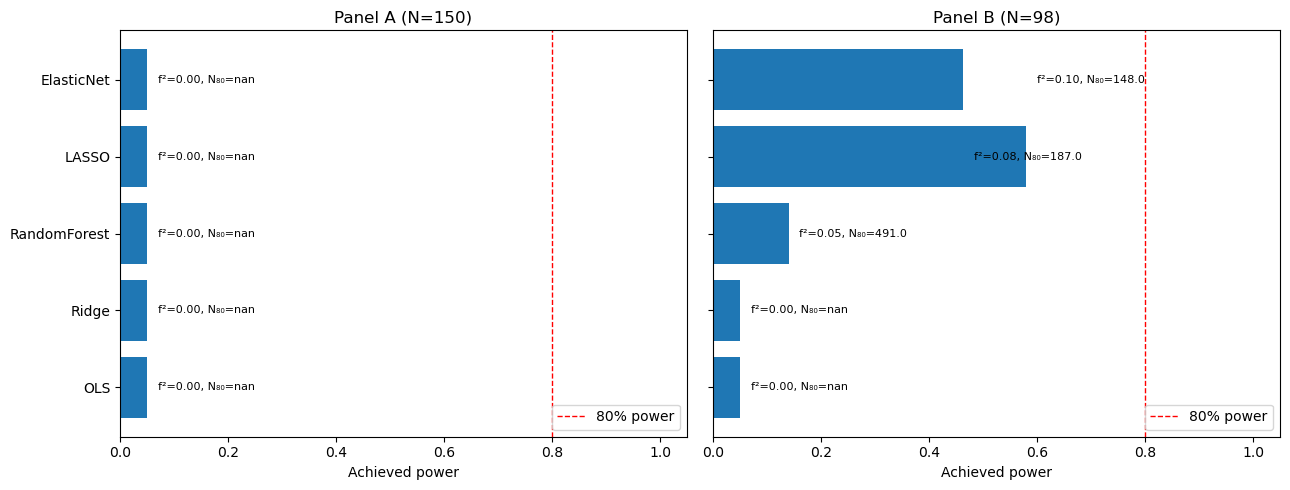

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, panel, df in [(axes[0], "A", posthoc_df[posthoc_df.Panel == "A"]),
                       (axes[1], "B", posthoc_df[posthoc_df.Panel == "B"])]:
    df = df.sort_values("achieved_power", ascending=True)
    ax.barh(df["Model"], df["achieved_power"], color="C0")
    ax.axvline(0.80, color="r", lw=1, linestyle="--", label="80% power")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Achieved power")
    ax.set_title(f"Panel {panel} (N={df.N.iloc[0]})")
    for yi, (_, row) in enumerate(df.iterrows()):
        nreq = row["N_required_for_80pct"]
        annot = f"f²={row.Cohen_f2:.2f}, N₈₀={nreq if nreq else '∞'}"
        ax.text(row.achieved_power + 0.02, yi, annot, va="center", fontsize=8)
    ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("figures/achieved_power_forest.pdf", dpi=300)
plt.show()


## 5. Per-feature partial η² (OLS, Panel A and Panel B)

`statsmodels` OLS with type-II ANOVA-style F partials. Tells us which features
contribute individually significantly to the fit, after controlling for the
others. Bootstrap 95% CIs from refits on resampled data.


In [7]:
def partial_eta2(X, y, feat_names, n_boot=200, seed=RNG_SEED):
    """Type-II partial η² per feature with bootstrap CIs.

    η² is bounded [0, 1] mathematically. On a bootstrap resample the reduced
    (feature-dropped) model can fit the resampled noise better than the full
    model, producing ss_extra < 0 and a meaningless negative η². We clip those
    to 0 before taking percentiles — equivalent to "we cannot detect that this
    feature contributes, on this resample." Same convention is used for the
    point estimate.
    """
    rng = np.random.default_rng(seed)
    sm_X = sm.add_constant(X.astype(float))
    full = sm.OLS(y, sm_X).fit()
    rows = []
    for j, name in enumerate(feat_names):
        col_idx = j + 1  # +1 for the const
        keep_cols = [i for i in range(sm_X.shape[1]) if i != col_idx]
        red = sm.OLS(y, sm_X[:, keep_cols]).fit()
        ss_extra = max(red.ssr - full.ssr, 0.0)
        eta2 = ss_extra / (ss_extra + full.ssr) if (ss_extra + full.ssr) > 0 else 0.0
        # Bootstrap
        boots = []
        for _ in range(n_boot):
            idx = rng.choice(len(y), len(y), replace=True)
            try:
                f_b = sm.OLS(y[idx], sm_X[idx]).fit()
                r_b = sm.OLS(y[idx], sm_X[idx][:, keep_cols]).fit()
                ss_e = max(r_b.ssr - f_b.ssr, 0.0)
                denom = ss_e + f_b.ssr
                boots.append(ss_e / denom if denom > 0 else 0.0)
            except Exception:
                continue
        if boots:
            lo, hi = np.percentile(boots, [2.5, 97.5])
        else:
            lo = hi = float("nan")
        rows.append({"feature": name, "partial_eta2": float(eta2),
                     "ci_lo": float(lo), "ci_hi": float(hi)})
    return pd.DataFrame(rows)


# Panel A — scale features (so eta² estimates are comparable across features
# of different magnitudes; required because SDY797's binary autoantibodies live
# alongside continuous values).
sc_A = MinMaxScaler().fit(Xa.values)
Xa_sc = sc_A.transform(Xa.values)
eta_A = partial_eta2(Xa_sc, ya.values, fa)
eta_A["Panel"] = "A"
print("Panel A partial η²:")
print(eta_A.to_string(index=False))

sc_B = MinMaxScaler().fit(Xb.values)
Xb_sc = sc_B.transform(Xb.values)
eta_B = partial_eta2(Xb_sc, yb.values, fb)
eta_B["Panel"] = "B"
print("\nPanel B partial η²:")
print(eta_B.to_string(index=False))

eta_all = pd.concat([eta_A, eta_B], ignore_index=True)
eta_all.to_csv("results/per_feature_partial_eta2.csv", index=False)


Panel A partial η²:
feature  partial_eta2    ci_lo        ci_hi Panel
   MIAA      0.006251 0.000036 3.593025e-02     A
  GAD65      0.018308 0.000117 9.468448e-02     A
  IA2IC      0.037785 0.001873 1.380900e-01     A
    ICA      0.001360 0.000002 3.365599e-02     A
   ZNT8      0.045230 0.003324 1.199237e-01     A
   8-12      0.000000 0.000000 4.012228e-16     A
  13-17      0.000000 0.000000 3.490110e-16     A
    >18      0.000000 0.000000 3.993892e-16     A
    Sex      0.046371 0.004675 1.412104e-01     A

Panel B partial η²:
                         feature  partial_eta2        ci_lo        ci_hi Panel
                             Sex      0.018836 2.739377e-05 1.208932e-01     B
                       age_years      0.004657 2.495463e-06 9.150994e-02     B
          disease_duration_years      0.024513 7.676945e-05 1.900118e-01     B
                             bmi      0.000510 6.128173e-05 8.747751e-02     B
                       height_cm      0.002904 1.826114e-05 1.03

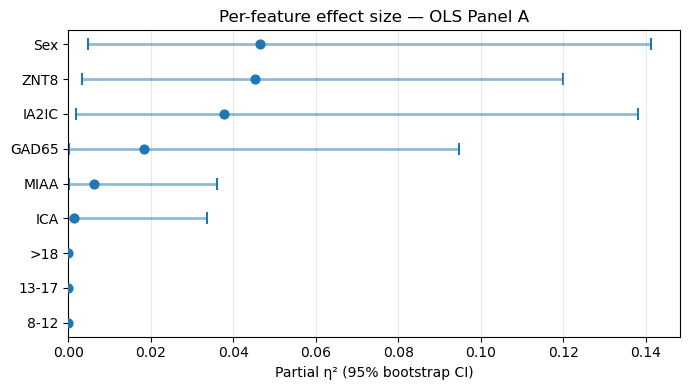

In [8]:
# Plot per-feature partial η² with CI bars (Panel A only — Panel B has 23
# features and gets crowded; the talk slide can use Panel A).
# Use scatter+hlines instead of barh+xerr: avoids matplotlib's hard requirement
# that xerr be non-negative when the point estimate falls outside the bootstrap
# CI (which can happen for tiny effects where bootstrap and exact computation
# disagree on noise).
df = eta_A.sort_values("partial_eta2", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(df))
ax.hlines(y_pos, df["ci_lo"], df["ci_hi"], color="C0", alpha=0.5, lw=2)
ax.scatter(df["partial_eta2"], y_pos, color="C0", zorder=3, s=40)
# Cap markers
ax.scatter(df["ci_lo"], y_pos, marker="|", color="C0", s=80)
ax.scatter(df["ci_hi"], y_pos, marker="|", color="C0", s=80)
ax.set_yticks(y_pos)
ax.set_yticklabels(df["feature"])
ax.set_xlabel("Partial η² (95% bootstrap CI)")
ax.set_xlim(left=0)
ax.set_title("Per-feature effect size — OLS Panel A")
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig("figures/per_feature_effects.pdf", dpi=300)
plt.show()


## 6. Inter-study heterogeneity (I² across per-study OLS slopes)

For each autoantibody, compute the per-study OLS slope and its standard error,
then aggregate via DerSimonian-Laird random-effects meta-analysis. I² quantifies
the share of slope variation that is between-study rather than sampling noise.


## DerSimonian-Laird 
DerSimonian and Laird (1986) is the canonical recipe for random-effects meta-analysis: a way of combining K independent estimates that does not assume they share an identical underlying effect. They allow for a between-study variance component τ² and weight each study by inverse variance.


In [9]:
def i_squared(slopes, ses):
    """DerSimonian-Laird I²."""
    slopes = np.asarray(slopes); ses = np.asarray(ses)
    w = 1.0 / ses**2
    mean = (w * slopes).sum() / w.sum()
    Q = (w * (slopes - mean) ** 2).sum()
    df = len(slopes) - 1
    if df <= 0:
        return float("nan"), Q, df
    I2 = max(0.0, (Q - df) / Q) if Q > 0 else 0.0
    return I2, Q, df

In [10]:
def per_study_slope(study_df, feature, target):
    sub = study_df.dropna(subset=[feature, target])
    if len(sub) < 5 or sub[feature].std() < 1e-9:
        return None
    sc = MinMaxScaler().fit(sub[[feature]].values)
    Xs = sm.add_constant(sc.transform(sub[[feature]].values))
    fit = sm.OLS(sub[target].values, Xs).fit()
    return float(fit.params[1]), float(fit.bse[1])

In [11]:
het_rows = []
ab_features = ["GAD65", "IA2IC", "MIAA", "ZNT8", "ICA"]
for ab in ab_features:
    slopes, ses, studies = [], [], []
    for s in od.PANEL_A_STUDIES:
        sub = A[A.Study == s]
        out = per_study_slope(sub, ab, od.PANEL_A_TARGET)
        if out is None:
            continue
        slope, se = out
        slopes.append(slope); ses.append(se); studies.append(s)
    if len(slopes) < 2:
        continue
    I2, Q, df = i_squared(slopes, ses)
    het_rows.append({"feature": ab, "n_studies": len(slopes),
                     "I2": I2, "Q": Q, "df": df,
                     "studies": ",".join(studies)})

het_df = pd.DataFrame(het_rows)
print(het_df.to_string(index=False))
het_df.to_csv("results/inter_study_heterogeneity.csv", index=False)

feature  n_studies       I2        Q  df                      studies
  GAD65          4 0.427328 5.238596   3 SDY524,SDY569,SDY797,SDY1737
  IA2IC          4 0.195956 3.731140   3 SDY524,SDY569,SDY797,SDY1737
   MIAA          4 0.000000 0.432368   3 SDY524,SDY569,SDY797,SDY1737
   ZNT8          3 0.000000 1.272857   2        SDY524,SDY797,SDY1737


## 7. Leave-one-study-out sensitivity

For each (model, dropped study) pair: fit on the remaining studies' data,
evaluate via 5-fold CV (now stratified by remaining-Study), and report Δ R²
and Δ achieved-power vs the full-data baseline. Tells us whether any one
study (especially SDY797 with binary autoantibodies, or SDY524 since it's
the largest single contributor) is driving the effect-size conclusions.


In [12]:
loso_rows = []
for dropped in od.PANEL_A_STUDIES:
    mask = A["Study"] != dropped
    A_drop = A[mask]
    if A_drop["Study"].nunique() < 2 or len(A_drop) < 30:
        print(f"Skipping LOSO for {dropped}: not enough remaining data")
        continue
    Xd = A_drop[fa].values
    yd = A_drop[od.PANEL_A_TARGET].values
    sd = A_drop["Study"].values
    for name, factory in model_factories_A.items():
        oof, k_eff = cv_oof_predict(factory, Xd, yd, sd)
        r2 = r2_score(yd, oof)
        f2 = cohens_f2(r2)
        k_use = int(k_eff) if k_eff and k_eff > 0 else len(fa)
        pwr = calc_power(len(yd), k_use, max(f2, 1e-6))
        loso_rows.append({"dropped": dropped, "Model": name, "N_remain": len(yd),
                          "R2_oof": r2, "Cohen_f2": f2, "achieved_power": pwr,
                          "k_used": k_use})

loso_df = pd.DataFrame(loso_rows)
print(loso_df.to_string(index=False))
loso_df.to_csv("results/leave_one_study_out_sensitivity.csv", index=False)

# Heatmap: rows = model, cols = dropped study, values = R²
pivot = loso_df.pivot(index="Model", columns="dropped", values="R2_oof")
print("\nR² (OOF) under leave-one-study-out:")
print(pivot.round(3).to_string())


dropped        Model  N_remain    R2_oof  Cohen_f2  achieved_power  k_used
 SDY524          OLS        75 -0.202568  0.000000        0.050002       9
 SDY524        Ridge        75 -0.202501  0.000000        0.050002       9
 SDY524        LASSO        75 -0.040241  0.000000        0.050002       9
 SDY524   ElasticNet        75 -0.035394  0.000000        0.050002       9
 SDY524 RandomForest        75 -0.103385  0.000000        0.050002       9
 SDY569          OLS       140  0.014218  0.014423        0.120844       9
 SDY569        Ridge       140  0.014232  0.014438        0.120927       9
 SDY569        LASSO       140 -0.053570  0.000000        0.050004       8
 SDY569   ElasticNet       140 -0.048734  0.000000        0.050004       8
 SDY569 RandomForest       140 -0.082181  0.000000        0.050004       9
 SDY797          OLS       101 -0.035820  0.000000        0.050003       9
 SDY797        Ridge       101 -0.035794  0.000000        0.050003       8
 SDY797        LASSO     

## 8. Summary table

One row per (model, panel): MSE, R² with 95% CI, Cohen's f², achieved power,
required N for 80% power. The closing slide for the talk's methods section.


In [13]:
# Pull MSE from the post-hoc effect-size pass
def cv_per_fold_mse(model_factory, X, y, study_labels, n_splits=N_FOLDS, seed=RNG_SEED):
    X = np.asarray(X); y = np.asarray(y)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fm = []
    for tr, te in skf.split(X, study_labels):
        m = model_factory()
        m.fit(X[tr], y[tr])
        fm.append(mean_squared_error(y[te], m.predict(X[te])))
    return np.asarray(fm)


summary_rows = []
for panel, X, y, feats, sl, factories in [
    ("A", Xa.values, ya.values, fa, A["Study"].values, model_factories_A),
    ("B", Xb.values, yb.values, fb, B["Study"].values, model_factories_B),
]:
    for name, factory in factories.items():
        fm = cv_per_fold_mse(factory, X, y, sl)
        oof, k_eff = cv_oof_predict(factory, X, y, sl)
        r2 = r2_score(y, oof)
        f2 = cohens_f2(r2)
        k_use = int(k_eff) if k_eff and k_eff > 0 else len(feats)
        pwr = calc_power(len(y), k_use, max(f2, 1e-6))
        nreq = required_n_for_power(max(f2, 1e-6), k_use)
        summary_rows.append({
            "Panel": panel, "Model": name, "N": len(y), "k": k_use,
            "MSE_mean": float(fm.mean()), "MSE_sd": float(fm.std()),
            "R2": r2, "Cohen_f2": f2,
            "achieved_power": pwr, "N_required_80pct": nreq,
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("results/talk_summary_table.csv", index=False)


Panel        Model   N  k  MSE_mean   MSE_sd        R2  Cohen_f2  achieved_power  N_required_80pct
    A          OLS 150  9  0.223936 0.056010 -0.026068  0.000000        0.050004               NaN
    A        Ridge 150  9  0.223932 0.056009 -0.026050  0.000000        0.050004               NaN
    A        LASSO 150  7  0.231918 0.073663 -0.062643  0.000000        0.050005               NaN
    A   ElasticNet 150  7  0.231510 0.073760 -0.060772  0.000000        0.050005               NaN
    A RandomForest 150  9  0.244504 0.058570 -0.120310  0.000000        0.050004               NaN
    B          OLS  98 23  0.216478 0.085381 -0.019092  0.000000        0.050001               NaN
    B        Ridge  98 21  0.216354 0.085403 -0.018495  0.000000        0.050001               NaN
    B        LASSO  98  6  0.193975 0.084615  0.088028  0.096525        0.580136             148.0
    B   ElasticNet  98  6  0.197589 0.087897  0.070332  0.075653        0.463406             187.0
    B Rand

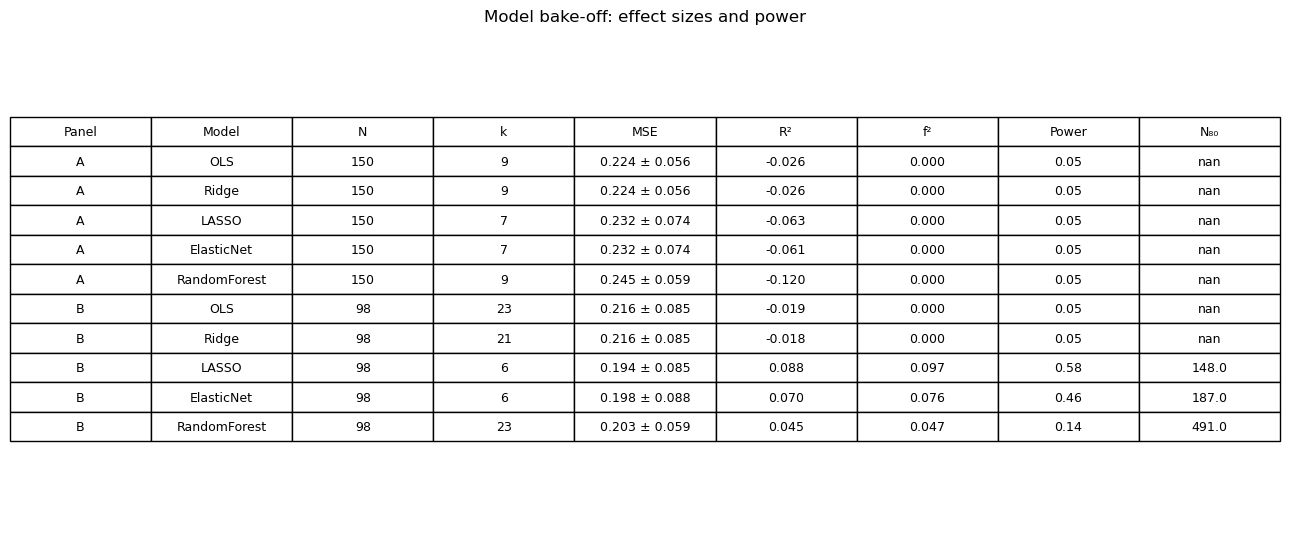

In [14]:
# Render the summary table as a publication-quality figure for the talk.
fig, ax = plt.subplots(figsize=(13, 0.4 * len(summary_df) + 1.5))
ax.axis("off")
display = summary_df.copy()
display["MSE"] = display.apply(lambda r: f"{r.MSE_mean:.3f} ± {r.MSE_sd:.3f}", axis=1)
display["R²"]  = display["R2"].map(lambda v: f"{v:.3f}")
display["f²"]  = display["Cohen_f2"].map(lambda v: f"{v:.3f}")
display["Power"] = display["achieved_power"].map(lambda v: f"{v:.2f}")
display["N₈₀"]  = display["N_required_80pct"].map(lambda v: "∞" if v is None else str(v))
display = display[["Panel", "Model", "N", "k", "MSE", "R²", "f²", "Power", "N₈₀"]]
table = ax.table(cellText=display.values,
                 colLabels=display.columns,
                 cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax.set_title("Model bake-off: effect sizes and power")
fig.tight_layout()
fig.savefig("figures/talk_summary_table.pdf", dpi=300)
plt.show()


## 9. Outputs

CSVs in `results/`:

- `effect_sizes_apriori.csv` — design-time power lookup table
- `effect_sizes_per_model.csv` — per-model R², f², power, N-required (both panels)
- `per_feature_partial_eta2.csv` — per-feature partial η² with bootstrap CIs
- `inter_study_heterogeneity.csv` — DerSimonian-Laird I² across per-study slopes
- `leave_one_study_out_sensitivity.csv` — drops each study in turn
- `talk_summary_table.csv` — the closing-slide table

Figures in `figures/`:

- `achieved_power_forest.pdf` — power per model, both panels
- `per_feature_effects.pdf` — partial η² bars (Panel A)
- `talk_summary_table.pdf` — rendered summary table

This completes the three-notebook suite.
